# Setup


In [1]:
import numpy as np
import pandas as pd
import pathlib
import pickle
import matplotlib.pyplot as plt
import json
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Definisikan Konstanta
LOOKBACK = 60
EPOCHS = 100
BATCH_SIZE = 32
PATIENCE = 10

PROCESSED_DIR = pathlib.Path('../data/processed')
MODELS_DIR = pathlib.Path('../models')
FIGURES_DIR = pathlib.Path('../reports/figures')

# Buat direktori jika belum ada
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Dictionary untuk menyimpan hasil
results = {}

# Load Data Array
X_train = np.load(PROCESSED_DIR / 'X_train.npy')
y_train = np.load(PROCESSED_DIR / 'y_train.npy')

X_val = np.load(PROCESSED_DIR / 'X_val.npy')
y_val = np.load(PROCESSED_DIR / 'y_val.npy')

X_test = np.load(PROCESSED_DIR / 'X_test.npy')
y_test = np.load(PROCESSED_DIR / 'y_test.npy')

# Load Scalers
with open(MODELS_DIR / 'scaler_X.pkl', 'rb') as f:
    scaler_X = pickle.load(f)
with open(MODELS_DIR / 'scaler_y.pkl', 'rb') as f:
    scaler_y = pickle.load(f)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}   | y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}   | y_test : {y_test.shape}")


X_train: (2302, 60, 11) | y_train: (2302,)
X_val  : (235, 60, 11)   | y_val  : (235,)
X_test : (236, 60, 11)   | y_test : (236,)


# Baseline Model (Linear Regression)


In [2]:
# Reshape data 3D menjadi 2D untuk algoritma Machine Learning tradisional
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)

# Training Baseline
baseline_model = LinearRegression()
baseline_model.fit(X_train_2d, y_train)
import pickle
with open(MODELS_DIR / 'baseline_model.pkl', 'wb') as f:
    pickle.dump(baseline_model, f)

# Prediksi menggunakan test set
y_pred_baseline_scaled = baseline_model.predict(X_test_2d)

# Inverse transform untuk mengembalikan nilai ke skala harga sebenarnya
y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_baseline_inv = scaler_y.inverse_transform(y_pred_baseline_scaled.reshape(-1, 1)).flatten()

# Hitung Metrik
rmse_base = np.sqrt(mean_squared_error(y_test_inv, y_pred_baseline_inv))
mae_base = mean_absolute_error(y_test_inv, y_pred_baseline_inv)
mape_base = mean_absolute_percentage_error(y_test_inv, y_pred_baseline_inv) * 100

results['baseline'] = {
    'rmse': rmse_base,
    'mae': mae_base,
    'mape': mape_base,
    'predictions': y_pred_baseline_inv.tolist()
}

print("=== Hasil Metrik Baseline (Linear Regression) ===")
print(f"RMSE: Rp {rmse_base:.2f}")
print(f"MAE : Rp {mae_base:.2f}")
print(f"MAPE: {mape_base:.2f}%")


=== Hasil Metrik Baseline (Linear Regression) ===
RMSE: Rp 147.24
MAE : Rp 111.58
MAPE: 3.26%


# Model LSTM (Long Short-Term Memory)


In [3]:
# Bangun Arsitektur LSTM
model_lstm = Sequential([
    Input(shape=(LOOKBACK, 11)),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_lstm.summary()

# Hitung Total Parameter LSTM untuk perbandingan
lstm_params = model_lstm.count_params()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,201 (481.25 KB)

 Trainable params: 123,201 (481.25 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Callback untuk EarlyStopping dan ModelCheckpoint
callbacks_lstm = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
    ModelCheckpoint(filepath=str(MODELS_DIR / 'lstm_antam.h5'), save_best_only=True, monitor='val_loss')
]

# Training LSTM
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks_lstm,
    verbose=1
)

epoch_lstm_actual = len(history_lstm.history['loss'])
print(f"\nEpoch aktual yang dijalankan (LSTM): {epoch_lstm_actual} epoch")


Epoch 1/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0123 - mae: 0.0714

72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0059 - mae: 0.0495 - val_loss: 9.5579e-04 - val_mae: 0.0241
Epoch 2/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0022 - mae: 0.0307

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0024 - mae: 0.0322 - val_loss: 7.0497e-04 - val_mae: 0.0210
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0019 - mae: 0.0291 - val_loss: 0.0018 - val_mae: 0.0368
Epoch 4/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0020 - mae: 0.0293

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0017 - mae: 0.0276 - val_loss: 6.0244e-04 - val_mae: 0.0196
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0016 - mae: 0.0258 - val_loss: 6.1834e-04 - val_mae: 0.0195
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0016 - mae: 0.0264 - val_loss: 0.0011 - val_mae: 0.0274
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0013 - mae: 0.0232 - val_loss: 0.0012 - val_mae: 0.0291
Epoch 8/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0013 - mae: 0.0236 - val_loss: 8.0392e-04 - val_mae: 0.0234
Epoch 9/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0013 - mae: 0.0230

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0012 - mae: 0.0223 - val_loss: 5.0464e-04 - val_mae: 0.0179
Epoch 10/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0011 - mae: 0.0219

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0011 - mae: 0.0221 - val_loss: 4.2930e-04 - val_mae: 0.0160
Epoch 11/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0013 - mae: 0.0232 - val_loss: 9.3253e-04 - val_mae: 0.0251
Epoch 12/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0013 - mae: 0.0241 - val_loss: 0.0012 - val_mae: 0.0301
Epoch 13/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 8.6220e-04 - mae: 0.0196

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0010 - mae: 0.0207 - val_loss: 4.0919e-04 - val_mae: 0.0159
Epoch 14/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 9.8883e-04 - mae: 0.0198 - val_loss: 5.9984e-04 - val_mae: 0.0197
Epoch 15/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 8.9712e-04 - mae: 0.0189 - val_loss: 6.4797e-04 - val_mae: 0.0209
Epoch 16/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 9.7191e-04 - mae: 0.0203 - val_loss: 6.6182e-04 - val_mae: 0.0206
Epoch 17/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 9.3498e-04 - mae: 0.0206 - val_loss: 6.7817e-04 - val_mae: 0.0215
Epoch 18/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 8.2402e-04 - mae: 0.0184 - val_loss: 0.0016 - val_mae: 0.0364
Epoch 19/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 7.6714e-04 - mae: 0.0183 - val_loss: 6.3100e-04 - val_mae: 0.0206
Epoch 20/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 7.4068e-04 - mae: 0.0175 - val_loss: 0.0014 - val_mae: 0.0331
Epoch 21/

In [5]:
# Prediksi & Evaluasi pada Test Set (X_test)
y_pred_lstm_scaled = model_lstm.predict(X_test)

# Inverse transform
y_pred_lstm_inv = scaler_y.inverse_transform(y_pred_lstm_scaled).flatten()

# Hitung Metrik
rmse_lstm = np.sqrt(mean_squared_error(y_test_inv, y_pred_lstm_inv))
mae_lstm = mean_absolute_error(y_test_inv, y_pred_lstm_inv)
mape_lstm = mean_absolute_percentage_error(y_test_inv, y_pred_lstm_inv) * 100

results['lstm'] = {
    'rmse': rmse_lstm,
    'mae': mae_lstm,
    'mape': mape_lstm,
    'epoch': epoch_lstm_actual,
    'params': lstm_params,
    'history': history_lstm.history,
    'predictions': y_pred_lstm_inv.tolist()
}

print("=== Hasil Metrik LSTM ===")
print(f"RMSE: Rp {rmse_lstm:.2f}")
print(f"MAE : Rp {mae_lstm:.2f}")
print(f"MAPE: {mape_lstm:.2f}%")


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
=== Hasil Metrik LSTM ===
RMSE: Rp 533.00
MAE : Rp 475.34
MAPE: 13.46%


# Model GRU (Gated Recurrent Unit)


In [6]:
# Bangun Arsitektur GRU yang IDENTIK dengan LSTM
model_gru = Sequential([
    Input(shape=(LOOKBACK, 11)),
    GRU(128, return_sequences=True),
    Dropout(0.2),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_gru.summary()

# Hitung Total Parameter GRU
gru_params = model_gru.count_params()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 128)        │        54,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,505 (365.25 KB)

 Trainable params: 93,505 (365.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Callback untuk EarlyStopping dan ModelCheckpoint
callbacks_gru = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
    ModelCheckpoint(filepath=str(MODELS_DIR / 'gru_antam.h5'), save_best_only=True, monitor='val_loss')
]

# Training GRU
history_gru = model_gru.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks_gru,
    verbose=1
)

epoch_gru_actual = len(history_gru.history['loss'])
print(f"\nEpoch aktual yang dijalankan (GRU): {epoch_gru_actual} epoch")


Epoch 1/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0116 - mae: 0.0687

72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.0052 - mae: 0.0460 - val_loss: 0.0017 - val_mae: 0.0365
Epoch 2/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0023 - mae: 0.0325

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0020 - mae: 0.0307 - val_loss: 0.0010 - val_mae: 0.0278
Epoch 3/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0017 - mae: 0.0266

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0017 - mae: 0.0270 - val_loss: 9.6503e-04 - val_mae: 0.0267
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0015 - mae: 0.0251 - val_loss: 0.0015 - val_mae: 0.0342
Epoch 5/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0015 - mae: 0.0259

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0015 - mae: 0.0253 - val_loss: 6.7570e-04 - val_mae: 0.0220
Epoch 6/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0013 - mae: 0.0236

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0013 - mae: 0.0233 - val_loss: 3.0074e-04 - val_mae: 0.0136
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0014 - mae: 0.0242 - val_loss: 0.0013 - val_mae: 0.0317
Epoch 8/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0013 - mae: 0.0233 - val_loss: 0.0019 - val_mae: 0.0402
Epoch 9/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0011 - mae: 0.0210 - val_loss: 0.0011 - val_mae: 0.0300
Epoch 10/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0012 - mae: 0.0216 - val_loss: 3.3120e-04 - val_mae: 0.0143
Epoch 11/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 8.9220e-04 - mae: 0.0195 - val_loss: 7.3613e-04 - val_mae: 0.0232
Epoch 12/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 9.6911e-04 - mae: 0.0201 - val_loss: 3.3366e-04 - val_mae: 0.0146
Epoch 13/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 9.9258e-04 - mae: 0.0201 - val_loss: 0.0014 - val_mae: 0.0339
Epoch 14/100
72/72 ━━━━━━━━━━━━━━━━━

In [8]:
# Prediksi & Evaluasi pada Test Set (X_test)
y_pred_gru_scaled = model_gru.predict(X_test)

# Inverse transform menggunakan scaler yang sama
y_pred_gru_inv = scaler_y.inverse_transform(y_pred_gru_scaled).flatten()

# Hitung Metrik
rmse_gru = np.sqrt(mean_squared_error(y_test_inv, y_pred_gru_inv))
mae_gru = mean_absolute_error(y_test_inv, y_pred_gru_inv)
mape_gru = mean_absolute_percentage_error(y_test_inv, y_pred_gru_inv) * 100

results['gru'] = {
    'rmse': rmse_gru,
    'mae': mae_gru,
    'mape': mape_gru,
    'epoch': epoch_gru_actual,
    'params': gru_params,
    'history': history_gru.history,
    'predictions': y_pred_gru_inv.tolist()
}

print("=== Hasil Metrik GRU ===")
print(f"RMSE: Rp {rmse_gru:.2f}")
print(f"MAE : Rp {mae_gru:.2f}")
print(f"MAPE: {mape_gru:.2f}%")


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
=== Hasil Metrik GRU ===
RMSE: Rp 313.23
MAE : Rp 265.56
MAPE: 7.53%


# Model Hybrid (Linear Regression + GRU)

Metodologi *Sequential Residual Modeling* menggabungkan kekuatan Linear Regression untuk menangkap tren linear dasar, dan GRU untuk memprediksi volatilitas/residual non-linear yang luput dari model regresi.
Langkah:
1. Menggunakan model Baseline (Linear Regression) untuk memprediksi `y_train_pred`.
2. Menghitung error residual dari data latih: `train_residuals = y_train - y_train_pred`.
3. Melatih model GRU (dengan arsitektur lebih ringan) untuk memprediksi nilai residual tersebut dari `X_train`.
4. Untuk *test set*, prediksi akhir adalah Prediksi Tren (Baseline) + Prediksi Residual (GRU).


In [9]:
# 1. Hitung Residual dari data latih menggunakan model Baseline
y_train_pred_lr_scaled = baseline_model.predict(X_train_2d)
train_residuals = y_train - y_train_pred_lr_scaled

# 2. Validasi residual di validation set
X_val_2d = X_val.reshape(X_val.shape[0], -1)
y_val_pred_lr_scaled = baseline_model.predict(X_val_2d)
val_residuals = y_val - y_val_pred_lr_scaled

# 3. Bangun Arsitektur GRU untuk Residual
model_gru_residual = Sequential([
    Input(shape=(LOOKBACK, 11)),
    GRU(64, return_sequences=True),
    Dropout(0.2),
    GRU(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model_gru_residual.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_gru_residual.summary()

gru_residual_params = model_gru_residual.count_params()

callbacks_hybrid = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
    ModelCheckpoint(filepath=str(MODELS_DIR / 'gru_residual_antam.h5'), save_best_only=True, monitor='val_loss')
]

print("\nMelatih GRU pada Residuals...")
history_hybrid = model_gru_residual.fit(
    X_train, train_residuals,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, val_residuals),
    callbacks=callbacks_hybrid,
    verbose=1
)

epoch_hybrid_actual = len(history_hybrid.history['loss'])
print(f"\nEpoch aktual yang dijalankan (Hybrid GRU): {epoch_hybrid_actual} epoch")


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 60, 64)         │        14,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,737 (96.63 KB)

 Trainable params: 24,737 (96.63 KB)

 Non-trainable params: 0 (0.00 B)


Melatih GRU pada Residuals...
Epoch 1/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0035 - mae: 0.0352

72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 0.0014 - mae: 0.0208 - val_loss: 2.5022e-04 - val_mae: 0.0124
Epoch 2/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.7996e-04 - mae: 0.0091

72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.7555e-04 - mae: 0.0091 - val_loss: 2.4101e-04 - val_mae: 0.0121
Epoch 3/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.7092e-04 - mae: 0.0091

72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 1.6307e-04 - mae: 0.0089 - val_loss: 2.4099e-04 - val_mae: 0.0121
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 1.4709e-04 - mae: 0.0085 - val_loss: 2.4166e-04 - val_mae: 0.0122
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 1.4002e-04 - mae: 0.0084 - val_loss: 2.4158e-04 - val_mae: 0.0122
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 1.3049e-04 - mae: 0.0081 - val_loss: 2.4153e-04 - val_mae: 0.0122
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 1.3530e-04 - mae: 0.0082 - val_loss: 2.4112e-04 - val_mae: 0.0121
Epoch 8/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 1.3394e-04 - mae: 0.0083 - val_loss: 2.4151e-04 - val_mae: 0.0122
Epoch 9/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 1.3424e-04 - mae: 0.0082 - val_loss: 2.4113e-04 - val_mae: 0.0121
Epoch 10/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 1.3001e-04 - mae: 0.0081 - val_loss: 2.4127e-04 - val_mae: 0.0122
Epo

In [10]:
# 4. Evaluasi pada Test Set (X_test)
# a. Prediksi tren dari Baseline
pred_test_lr_scaled = baseline_model.predict(X_test_2d)

# b. Prediksi residual dari GRU
pred_test_residual_scaled = model_gru_residual.predict(X_test).flatten()

# c. Gabungkan
y_pred_hybrid_scaled = pred_test_lr_scaled + pred_test_residual_scaled

# d. Inverse Transform gabungan
y_pred_hybrid_inv = scaler_y.inverse_transform(y_pred_hybrid_scaled.reshape(-1, 1)).flatten()

# Hitung Metrik
rmse_hybrid = np.sqrt(mean_squared_error(y_test_inv, y_pred_hybrid_inv))
mae_hybrid = mean_absolute_error(y_test_inv, y_pred_hybrid_inv)
mape_hybrid = mean_absolute_percentage_error(y_test_inv, y_pred_hybrid_inv) * 100

results['hybrid'] = {
    'rmse': rmse_hybrid,
    'mae': mae_hybrid,
    'mape': mape_hybrid,
    'epoch': epoch_hybrid_actual,
    'params': gru_residual_params,
    'history': history_hybrid.history,
    'predictions': y_pred_hybrid_inv.tolist()
}

print("=== Hasil Metrik Hybrid (LR + GRU) ===")
print(f"RMSE: Rp {rmse_hybrid:.2f}")
print(f"MAE : Rp {mae_hybrid:.2f}")
print(f"MAPE: {mape_hybrid:.2f}%")


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step
=== Hasil Metrik Hybrid (LR + GRU) ===
RMSE: Rp 147.60
MAE : Rp 111.85
MAPE: 3.27%


# Visualisasi Perbandingan


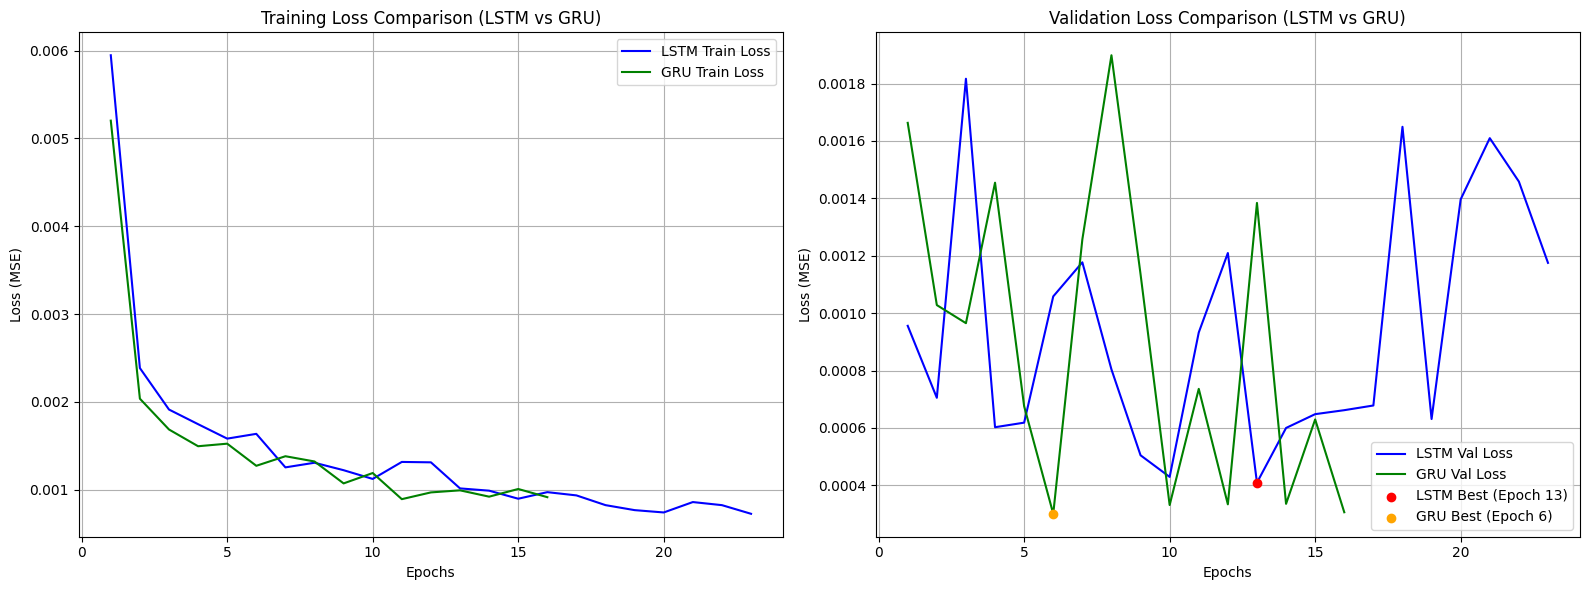

In [11]:
# Visualisasi Kurva Loss (Training vs Validation) untuk LSTM dan GRU
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

epochs_lstm = range(1, len(history_lstm.history['loss']) + 1)
epochs_gru = range(1, len(history_gru.history['loss']) + 1)

# Titik Early Stopping
es_point_lstm = np.argmin(history_lstm.history['val_loss']) + 1
es_point_gru = np.argmin(history_gru.history['val_loss']) + 1

# Plot Training Loss
axes[0].plot(epochs_lstm, history_lstm.history['loss'], label='LSTM Train Loss', color='blue')
axes[0].plot(epochs_gru, history_gru.history['loss'], label='GRU Train Loss', color='green')
axes[0].set_title('Training Loss Comparison (LSTM vs GRU)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True)

# Plot Validation Loss
axes[1].plot(epochs_lstm, history_lstm.history['val_loss'], label='LSTM Val Loss', color='blue')
axes[1].plot(epochs_gru, history_gru.history['val_loss'], label='GRU Val Loss', color='green')
axes[1].scatter(es_point_lstm, history_lstm.history['val_loss'][es_point_lstm-1], color='red', zorder=5, label=f'LSTM Best (Epoch {es_point_lstm})')
axes[1].scatter(es_point_gru, history_gru.history['val_loss'][es_point_gru-1], color='orange', zorder=5, label=f'GRU Best (Epoch {es_point_gru})')
axes[1].set_title('Validation Loss Comparison (LSTM vs GRU)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss (MSE)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'loss_curve_comparison.png')
plt.show()


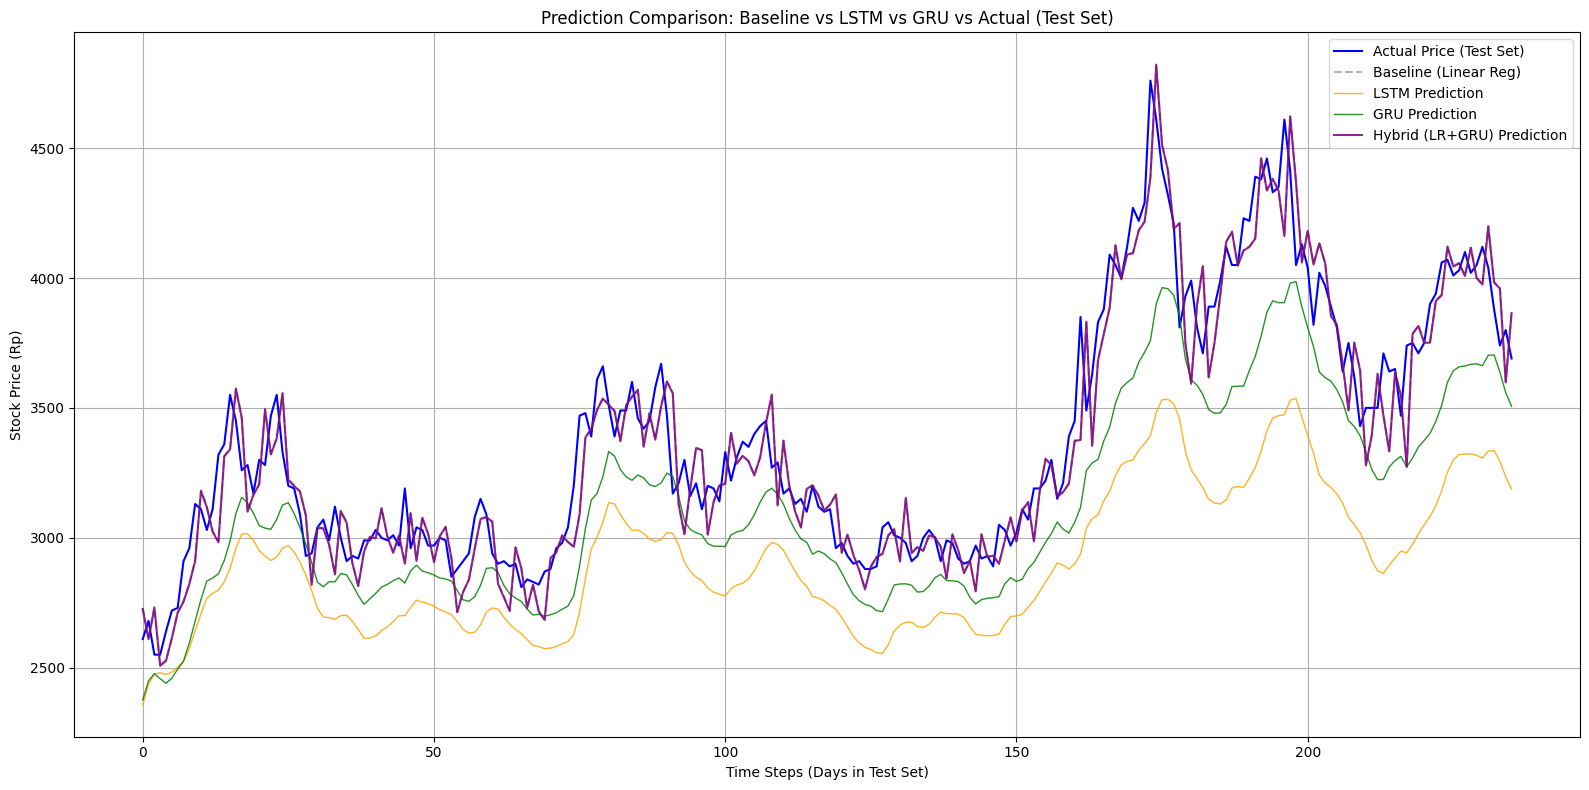

In [12]:
# Visualisasi Prediksi vs Harga Aktual pada X_test
plt.figure(figsize=(16, 8))

# Data aktual
plt.plot(y_test_inv, color='blue', linewidth=1.5, label='Actual Price (Test Set)')

# Prediksi Model
plt.plot(y_pred_baseline_inv, color='gray', linestyle='--', alpha=0.6, label='Baseline (Linear Reg)')
plt.plot(y_pred_lstm_inv, color='orange', linewidth=1, alpha=0.85, label='LSTM Prediction')
plt.plot(y_pred_gru_inv, color='green', linewidth=1, alpha=0.85, label='GRU Prediction')
plt.plot(y_pred_hybrid_inv, color='purple', linewidth=1.5, alpha=0.85, label='Hybrid (LR+GRU) Prediction')

plt.title('Prediction Comparison: Baseline vs LSTM vs GRU vs Actual (Test Set)')
plt.xlabel('Time Steps (Days in Test Set)')
plt.ylabel('Stock Price (Rp)')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'prediction_comparison.png')
plt.show()


# Tabel Perbandingan Final


In [13]:
# Konfigurasi DataFrame agar tampilan tabel lebih rapi
df_results = pd.DataFrame({
    'Model': ['Baseline', 'LSTM', 'GRU', 'Hybrid'],
    'RMSE (Rp)': [results['baseline']['rmse'], results['lstm']['rmse'], results['gru']['rmse'], results['hybrid']['rmse']],
    'MAE (Rp)': [results['baseline']['mae'], results['lstm']['mae'], results['gru']['mae'], results['hybrid']['mae']],
    'MAPE (%)': [results['baseline']['mape'], results['lstm']['mape'], results['gru']['mape'], results['hybrid']['mape']],
    'Parameters': ['N/A', f"{results['lstm']['params']:,}", f"{results['gru']['params']:,}", f"{results['hybrid']['params']:,}"],
    'Epochs': ['N/A', results['lstm']['epoch'], results['gru']['epoch'], results['hybrid']['epoch']]
})

# Menampilkan tabel
print("=== Tabel Perbandingan Model ===")
display(df_results)

# Kalkulasi selisih spesifik LSTM vs GRU
best_model_rmse = 'LSTM' if results['lstm']['rmse'] < results['gru']['rmse'] else 'GRU'
rmse_diff = abs(results['lstm']['rmse'] - results['gru']['rmse'])
rmse_diff_pct = (rmse_diff / max(results['lstm']['rmse'], results['gru']['rmse'])) * 100

best_model_epoch = 'LSTM' if results['lstm']['epoch'] < results['gru']['epoch'] else 'GRU'
epoch_diff = abs(results['lstm']['epoch'] - results['gru']['epoch'])

param_diff = results['lstm']['params'] - results['gru']['params']
param_diff_pct = (param_diff / results['lstm']['params']) * 100

print("\n=== Analisis Lanjutan LSTM vs GRU ===")
print(f"- Dari segi akurasi (RMSE), {best_model_rmse} lebih baik dengan selisih Rp {rmse_diff:.2f} ({rmse_diff_pct:.2f}%).")
print(f"- Dari segi waktu konvergensi, {best_model_epoch} mencapai early stopping lebih cepat dengan selisih {epoch_diff} epoch.")
print(f"- Arsitektur GRU memiliki {param_diff:,} ({param_diff_pct:.2f}%) parameter lebih sedikit dibandingkan LSTM.")


=== Tabel Perbandingan Model ===


,Model,RMSE (Rp),MAE (Rp),MAPE (%),Parameters,Epochs
0,Baseline,147.244400,111.576123,3.259491,N/A,N/A
1,LSTM,532.997587,475.340158,13.457808,"123,201",23
2,GRU,313.233286,265.555814,7.534537,"93,505",16
3,Hybrid,147.602708,111.853787,3.267460,"24,737",13



=== Analisis Lanjutan LSTM vs GRU ===
- Dari segi akurasi (RMSE), GRU lebih baik dengan selisih Rp 219.76 (41.23%).
- Dari segi waktu konvergensi, GRU mencapai early stopping lebih cepat dengan selisih 7 epoch.
- Arsitektur GRU memiliki 29,696 (24.10%) parameter lebih sedikit dibandingkan LSTM.


In [14]:
# Simpan results ke dalam JSON agar dapat digunakan di notebook evaluasi
json_results = {
    'baseline': {k: v for k, v in results['baseline'].items() if k not in ['predictions']},
    'lstm': {k: v for k, v in results['lstm'].items() if k not in ['history', 'predictions']},
    'gru': {k: v for k, v in results['gru'].items() if k not in ['history', 'predictions']},
    'hybrid': {k: v for k, v in results['hybrid'].items() if k not in ['history', 'predictions']}
}

with open(MODELS_DIR / 'results_summary.json', 'w') as f:
    json.dump(json_results, f, indent=2)
    
print(f"Results (metrik komparasi) disimpan ke {MODELS_DIR / 'results_summary.json'}")

# Simpan array hasil prediksi untuk digunakan di notebook visualisasi final
np.save(PROCESSED_DIR / 'y_test_inv.npy', y_test_inv)
np.save(PROCESSED_DIR / 'y_pred_baseline_inv.npy', y_pred_baseline_inv)
np.save(PROCESSED_DIR / 'y_pred_lstm_inv.npy', y_pred_lstm_inv)
np.save(PROCESSED_DIR / 'y_pred_gru_inv.npy', y_pred_gru_inv)
np.save(PROCESSED_DIR / 'y_pred_hybrid_inv.npy', y_pred_hybrid_inv)
print(f"Array prediksi disimpan di {PROCESSED_DIR}")


Results (metrik komparasi) disimpan ke ..\models\results_summary.json
Array prediksi disimpan di ..\data\processed
